In [ ]:
from pathlib import Path
import pandas as pd

#we create the dataframe and extract columns gender, titulaire_soutien, party_list
data = []

base_path = Path("text_files")

for year in base_path.iterdir():
    for election in year.iterdir():
        for file in election.glob("*.txt"):
            text = file.read_text()
            data.append({
                "year": year.name,
                "election": election.name,
                "text": text,
                "filename": file.stem
            })

df = pd.DataFrame(data)
print(df.head())

   year      election                                               text  \
0  1973  legislatives  7e circonscription de Paris\nJean DEMARE\nIngé...   
1  1973  legislatives  Sciences Po / fonds CEVIPOF\nÉLECTIONS LÉGISLA...   
2  1973  legislatives  Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...   
3  1973  legislatives  Sciences Po / fonds CEVIPOF\nÉLECTIONS LÉGISLA...   
4  1973  legislatives  ÉLECTIONS LÉGISLATIVES - MARS 1973 - 7e CIRCON...   

                                   filename  
0            EL068_L_1973_03_075_07_1_PF_10  
1            EL069_L_1973_03_085_03_1_PF_05  
2            EL067_L_1973_03_057_04_1_PF_03  
3  EL068_L_1973_03_067_03_1_BV_pdfmasterocr  
4            EL069_L_1973_03_092_07_1_PF_01  


<Axes: xlabel='count', ylabel='election'>

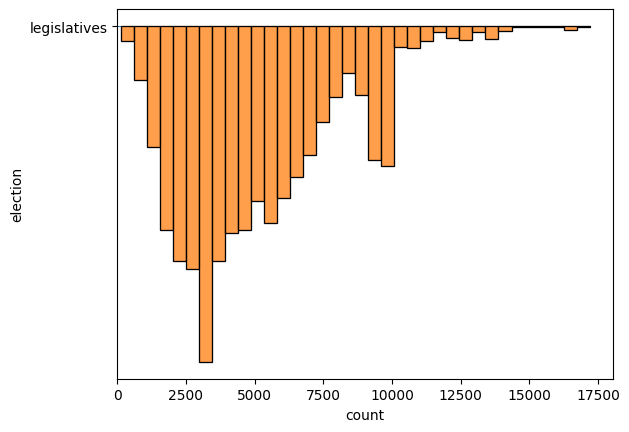

In [6]:
import seaborn as sns

#we visualize the distribution of elections and text lengths
sns.countplot(data=df, y="election")
df["length"] = df["text"].apply(len)
sns.histplot(df["length"])

In [ ]:
#detecting gender style
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

vectorizer = TfidfVectorizer(max_features=2000)
X = vectorizer.fit_transform(df["text"])


clf = LogisticRegression()
clf.fit(X_train, y_train)

In [ ]:
#detecting party style
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["party_list"], test_size=0.2
)

vectorizer = CountVectorizer(max_features=1000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf = MultinomialNB()
clf.fit(X_train_vec, y_train)

print("Accuracy:", clf.score(X_test_vec, y_test))

In [ ]:
#same for TfidfVectorizer instead of CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=2000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf = MultinomialNB()
clf.fit(X_train_vec, y_train)

print("Accuracy:", clf.score(X_test_vec, y_test))

In [ ]:
#creating confusion matrix

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred = clf.predict(X_test_vec)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)